In [ ]:
import pandas as pd
from google.colab import files

# Upload file
uploaded = files.upload()


Saving labeled_data.csv to labeled_data.csv


In [ ]:
# Load CSV using pandas
df = pd.read_csv("labeled_data.csv")

# View dataset
df.head()


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [ ]:
df.columns


Index(['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither',
       'class', 'tweet'],
      dtype='object')

In [ ]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout


In [ ]:
import re

# Keep only necessary columns
df = df[['tweet', 'class']]
df.columns = ['text', 'label']

# Convert labels to binary
# 0,1 → Abusive (1)
# 2 → Non-abusive (0)
df['label'] = df['label'].apply(lambda x: 1 if x in [0,1] else 0)

# Clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df['text'] = df['text'].apply(clean_text)

df.head()


,text,label
0,rt as a woman you shouldnt complain about cl...,0
1,rt boy dats coldtyga dwn bad for cuffin dat ...,1
2,rt dawg rt you ever fuck a bitch and she st...,1
3,rt she look like a tranny,1
4,rt the shit you hear about me might be true ...,1


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)


In [ ]:
## Tokenization and Padding
# Vocabulary size
VOCAB_SIZE = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')


In [ ]:
model_lstm = Sequential([
    Embedding(VOCAB_SIZE, 128, input_length=MAX_LEN),
    LSTM(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


279/279 ━━━━━━━━━━━━━━━━━━━━ 39s 129ms/step - accuracy: 0.8261 - loss: 0.4692 - val_accuracy: 0.8366 - val_loss: 0.4472
Epoch 2/5
279/279 ━━━━━━━━━━━━━━━━━━━━ 35s 124ms/step - accuracy: 0.8262 - loss: 0.4676 - val_accuracy: 0.8366 - val_loss: 0.4453
Epoch 3/5
279/279 ━━━━━━━━━━━━━━━━━━━━ 34s 123ms/step - accuracy: 0.8321 - loss: 0.4589 - val_accuracy: 0.8366 - val_loss: 0.4464
Epoch 4/5
279/279 ━━━━━━━━━━━━━━━━━━━━ 35s 126ms/step - accuracy: 0.8315 - loss: 0.4603 - val_accuracy: 0.8366 - val_loss: 0.4455
Epoch 5/5
279/279 ━━━━━━━━━━━━━━━━━━━━ 36s 129ms/step - accuracy: 0.8273 - loss: 0.4646 - val_accuracy: 0.8366 - val_loss: 0.4453


In [ ]:
loss_lstm, acc_lstm = model_lstm.evaluate(X_test_pad, y_test)
print("LSTM Accuracy:", acc_lstm)


155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.8332 - loss: 0.4508
LSTM Accuracy: 0.831954836845398


In [ ]:
from tensorflow.keras.layers import Bidirectional

model_bilstm = Sequential([
    Embedding(VOCAB_SIZE, 128, input_length=MAX_LEN),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_bilstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_bilstm = model_bilstm.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)


Epoch 1/5
279/279 ━━━━━━━━━━━━━━━━━━━━ 66s 223ms/step - accuracy: 0.8486 - loss: 0.3491 - val_accuracy: 0.9415 - val_loss: 0.1308
Epoch 2/5
279/279 ━━━━━━━━━━━━━━━━━━━━ 61s 219ms/step - accuracy: 0.9600 - loss: 0.1089 - val_accuracy: 0.9465 - val_loss: 0.1193
Epoch 3/5
279/279 ━━━━━━━━━━━━━━━━━━━━ 82s 220ms/step - accuracy: 0.9792 - loss: 0.0662 - val_accuracy: 0.9470 - val_loss: 0.1372
Epoch 4/5
279/279 ━━━━━━━━━━━━━━━━━━━━ 81s 215ms/step - accuracy: 0.9883 - loss: 0.0374 - val_accuracy: 0.9440 - val_loss: 0.1715
Epoch 5/5
279/279 ━━━━━━━━━━━━━━━━━━━━ 62s 221ms/step - accuracy: 0.9902 - loss: 0.0287 - val_accuracy: 0.9385 - val_loss: 0.2600


In [ ]:
loss_bilstm, acc_bilstm = model_bilstm.evaluate(X_test_pad, y_test)
print("BiLSTM Accuracy:", acc_bilstm)


155/155 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.9414 - loss: 0.2469
BiLSTM Accuracy: 0.9400847554206848


In [ ]:
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

model_cnn = Sequential([
    Embedding(VOCAB_SIZE, 128, input_length=MAX_LEN),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_cnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_cnn = model_cnn.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)


Epoch 1/5
279/279 ━━━━━━━━━━━━━━━━━━━━ 28s 93ms/step - accuracy: 0.8695 - loss: 0.3294 - val_accuracy: 0.9576 - val_loss: 0.1100
Epoch 2/5
279/279 ━━━━━━━━━━━━━━━━━━━━ 26s 92ms/step - accuracy: 0.9627 - loss: 0.1008 - val_accuracy: 0.9506 - val_loss: 0.1133
Epoch 3/5
279/279 ━━━━━━━━━━━━━━━━━━━━ 41s 92ms/step - accuracy: 0.9832 - loss: 0.0584 - val_accuracy: 0.9460 - val_loss: 0.1353
Epoch 4/5
279/279 ━━━━━━━━━━━━━━━━━━━━ 42s 94ms/step - accuracy: 0.9909 - loss: 0.0322 - val_accuracy: 0.9450 - val_loss: 0.1593
Epoch 5/5
279/279 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.9927 - loss: 0.0239 - val_accuracy: 0.9440 - val_loss: 0.1877


In [ ]:
loss_cnn, acc_cnn = model_cnn.evaluate(X_test_pad, y_test)
print("CNN Accuracy:", acc_cnn)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9386 - loss: 0.2040
CNN Accuracy: 0.9402864575386047


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
def evaluate_model(model, X_test, y_test, model_name):

    y_pred_prob = model.predict(X_test)

    y_pred = (y_pred_prob > 0.5).astype(int)

    print(f"\n📊 Classification Report for {model_name}")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    print(f"\n🔢 Confusion Matrix for {model_name}")
    print(cm)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


155/155 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step

📊 Classification Report for LSTM
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       833
           1       0.83      1.00      0.91      4124

    accuracy                           0.83      4957
   macro avg       0.42      0.50      0.45      4957
weighted avg       0.69      0.83      0.76      4957


🔢 Confusion Matrix for LSTM
[[   0  833]
 [   0 4124]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


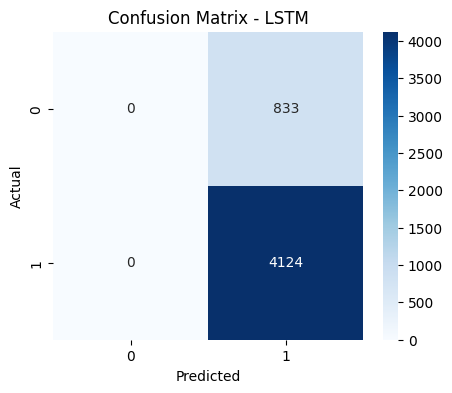

155/155 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step

📊 Classification Report for BiLSTM
              precision    recall  f1-score   support

           0       0.82      0.83      0.82       833
           1       0.97      0.96      0.96      4124

    accuracy                           0.94      4957
   macro avg       0.89      0.90      0.89      4957
weighted avg       0.94      0.94      0.94      4957


🔢 Confusion Matrix for BiLSTM
[[ 692  141]
 [ 156 3968]]


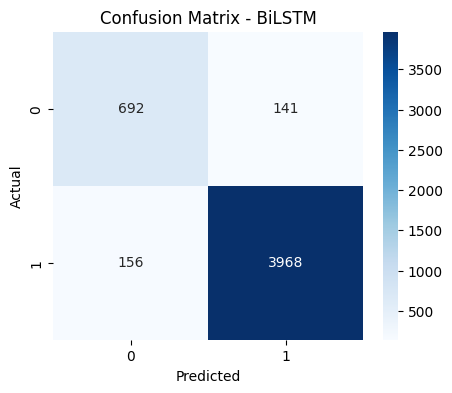

155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step

📊 Classification Report for CNN
              precision    recall  f1-score   support

           0       0.82      0.83      0.82       833
           1       0.97      0.96      0.96      4124

    accuracy                           0.94      4957
   macro avg       0.89      0.90      0.89      4957
weighted avg       0.94      0.94      0.94      4957


🔢 Confusion Matrix for CNN
[[ 692  141]
 [ 156 3968]]


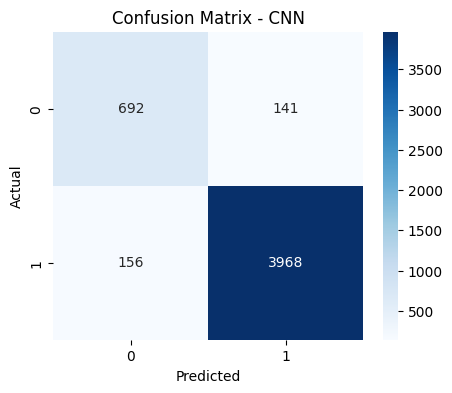

In [ ]:
evaluate_model(model_lstm, X_test_pad, y_test, "LSTM")
evaluate_model(model_bilstm, X_test_pad, y_test, "BiLSTM")
evaluate_model(model_cnn, X_test_pad, y_test, "CNN")

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["LSTM", "BiLSTM", "CNN"],
    "Accuracy": [acc_lstm, acc_bilstm, acc_cnn]
})

results


,Model,Accuracy
0,LSTM,0.831955
1,BiLSTM,0.940085
2,CNN,0.940286


In [ ]:
model_bilstm.save("abusive_language_bilstm_model.h5")


In [ ]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)


In [ ]:
def predict_abusive_final(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    prob = model_cnn.predict(pad)[0][0]
    return "Abusive" if prob > 0.5 else "Safe"


In [ ]:
tests = [
    "I will kill you",
    "Good morning everyone",
    "You are useless",
    "I will hurt you badly",

]

for t in tests:
    print(t, "→", predict_abusive_final(t))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
I will kill you → Abusive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Good morning everyone → Safe
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
You are useless → Abusive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
I will hurt you badly → Safe


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving 3.wav to 3.wav


In [ ]:
!pip install -U openai-whisper
!apt-get install -y ffmpeg


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 11.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 6.2 MB/s eta 0:00:00
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803980 sha256=5c0301ace9fa5427d55999f6ee3468088d5ca7e72d756ad78df7521980d116d0
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
import whisper
asr_model = whisper.load_model("small")


In [ ]:
from tensorflow.keras.models import load_model
import pickle

model_cnn = load_model("abusive_language_bilstm_model.h5")

with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_from_uploaded_audio(audio_path):

    result = asr_model.transcribe(audio_path)
    text = result["text"]

    print("Transcribed Text:", text)
    text = clean_text(text)

    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post')

    prob = model_bilstm.predict(pad)[0][0]

    print("Probability:", prob)

    if prob > 0.5:
        print("Prediction: Abusive")
    else:
        print("Prediction: Safe")



In [ ]:
predict_from_uploaded_audio("3.wav")


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Transcribed Text:  You are a loser.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step
Probability: 0.9803661
Prediction: 🚨 Abusive
